# Laboratorio 5 - Reto Babel
## Aplicación de Atención y Transformers

**Modalidad:** grupos de hasta 3 integrantes  
**Entrega:** domingo 6 de septiembre de 2026, 23:59  
**Archivo:** `S09_Lab05_Reto_Babel_ESTUDIANTE.ipynb`  
**Valor:** 100 puntos

Su misión es entrenar un traductor de un idioma inventado al español utilizando PyTorch.

El diccionario ayuda a reconocer las palabras, pero el modelo debe aprender a reorganizarlas. En el
idioma secreto el verbo aparece al final, el adjetivo antes del sustantivo y la negación después del verbo.

### Reglas

- Use únicamente PyTorch y la biblioteca estándar de Python. No use NumPy.
- Use `nn.Transformer`; no reimplemente internamente la atención multi-cabeza.
- No use modelos preentrenados, traductores externos ni APIs generativas.
- No modifique las celdas de verificación.
- Entregue el notebook ejecutado, con las respuestas y salidas visibles.

## Bloque 0 - Investigación guiada (20 puntos)

Lea las secciones 1, 3.1, 3.2 y 3.5 de [*Attention Is All You Need*](https://arxiv.org/abs/1706.03762)
y consulte la [documentación de `nn.Transformer`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Transformer.html).

Responda con lenguaje sencillo y cite el enlace utilizado. Estas son las **únicas cuatro preguntas de
investigación** del laboratorio:

1. ¿Qué limitación de los modelos recurrentes buscaba resolver el Transformer y por qué la traducción era una tarea importante para demostrarlo?
2. ¿Qué trabajo realizan el encoder, la self-attention enmascarada del decoder y la atención entre decoder y encoder en un traductor?
3. ¿Por qué el Transformer necesita información posicional y qué espera que ocurra en este laboratorio si se elimina?
4. ¿Qué ventaja y qué costo de la atención frente a la recurrencia identifica en el artículo, y cómo se relacionan con las frases cortas del Reto Babel?

### Respuestas del grupo

**1.** Los modelos recurrentes procesan una secuencia paso a paso: para calcular el estado de una posición necesitan el estado anterior. Esa dependencia hace difícil paralelizar el entrenamiento dentro de una misma frase, especialmente cuando las secuencias crecen. El Transformer buscó eliminar esa recurrencia y usar atención para relacionar directamente las posiciones. La traducción era una prueba importante porque es una tarea de secuencia a secuencia exigente: el modelo debe comprender la oración de entrada y producir otra oración ordenada correctamente. El artículo mostró que podía mejorar la calidad de traducción y, al mismo tiempo, entrenarse con más paralelismo.

**Fuente:** https://arxiv.org/abs/1706.03762

**2.** El **encoder** recibe toda la oración del idioma secreto y construye una representación contextual de cada palabra, dejando que cada posición atienda a las demás. En el **decoder**, la self-attention enmascarada solo permite mirar las palabras españolas ya conocidas o generadas, no las futuras; así se mantiene la generación autoregresiva. Después, la atención entre **decoder y encoder** permite que cada posición del decoder consulte las representaciones de toda la oración de entrada para decidir qué información usar al predecir la siguiente palabra. En `nn.Transformer`, esto se implementa con las secuencias `src` y `tgt`, una máscara causal para `tgt` y máscaras de padding para ignorar `<PAD>`.

**Fuentes:** https://arxiv.org/abs/1706.03762 y https://docs.pytorch.org/docs/stable/generated/torch.nn.Transformer.html

**3.** La atención por sí sola no incluye una noción del orden: si no se agrega información extra, el modelo sabe qué palabras están presentes, pero no cuál está en la primera, segunda o tercera posición. Como el Transformer no tiene recurrencia ni convolución, el artículo agrega codificaciones posicionales a los embeddings. En este laboratorio espero que quitar la posición perjudique especialmente el reordenamiento de la oración y, por lo tanto, aumente la pérdida de validación o reduzca la exactitud. Sin embargo, como las frases son cortas y el conjunto tiene patrones repetitivos, el modelo sin posición todavía podría aprender parte de la tarea.

**Fuente:** https://arxiv.org/abs/1706.03762

**4.** Una ventaja de la self-attention es que conecta posiciones distantes con pocas operaciones secuenciales y permite procesar muchas posiciones en paralelo, mientras una red recurrente necesita avanzar posición por posición. El costo es que la atención completa compara pares de posiciones y su complejidad respecto al largo de la secuencia crece aproximadamente de forma cuadrática, $O(n^2 d)$. En el Reto Babel las frases son muy cortas (en estos datos llegan a 7 palabras antes de agregar tokens especiales), así que ese costo cuadrático es pequeño y la ventaja de trabajar con todas las posiciones a la vez resulta apropiada.

**Fuente:** https://arxiv.org/abs/1706.03762


## Bloque 1 - Preparar el entorno y explorar los datos (5 puntos)

Cargue los tres CSV recibidos. Verifique cuántos ejemplos tiene y observe cómo cambia el orden entre
el idioma secreto y el español. El diccionario es una ayuda; el modelo debe aprender la transformación.

In [1]:
from __future__ import annotations

import csv
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

SEMILLA = 42
random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DISPOSITIVO)

# En CPU, un solo hilo evita sobrecarga para este modelo pequeño y hace la ejecución más estable.
if DISPOSITIVO.type == "cpu":
    torch.set_num_threads(1)

# Ejemplos de funciones utilizadas en este bloque:
# torch.manual_seed(...), torch.device(...), torch.cuda.is_available()

Dispositivo: cpu


In [2]:
# Los tres CSV del grupo están en la subcarpeta data.
CARPETA_DATOS = Path("data")

# Ejemplos de funciones utilizadas en este bloque:
# Path("carpeta"), Path.exists(), Path / "archivo.csv"
assert CARPETA_DATOS.exists(), "Actualice CARPETA_DATOS con la carpeta recibida."
assert all((CARPETA_DATOS / nombre).exists() for nombre in (
    "entrenamiento.csv", "validacion.csv", "diccionario.csv"
)), "Los tres CSV deben estar en la subcarpeta data."


In [3]:
def leer_pares(ruta: Path):
    with ruta.open(encoding="utf-8", newline="") as archivo:
        return list(csv.DictReader(archivo))


class Vocabulario:
    ESPECIALES = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]

    def __init__(self, tokens):
        unicos = self.ESPECIALES + sorted(set(tokens) - set(self.ESPECIALES))
        self.token_a_id = {token: i for i, token in enumerate(unicos)}
        self.id_a_token = {i: token for token, i in self.token_a_id.items()}

    def __len__(self):
        return len(self.token_a_id)

    def codificar(self, texto, agregar_inicio_fin=True):
        ids = [self.token_a_id.get(token, self.token_a_id["<UNK>"]) for token in texto.split()]
        if agregar_inicio_fin:
            ids = [self.token_a_id["<SOS>"]] + ids + [self.token_a_id["<EOS>"]]
        return ids

    def decodificar(self, ids):
        tokens = []
        for indice in ids:
            token = self.id_a_token[int(indice)]
            if token == "<EOS>":
                break
            if token not in {"<PAD>", "<SOS>"}:
                tokens.append(token)
        return " ".join(tokens)


class ParesTraduccion(Dataset):
    def __init__(self, pares, vocab_src, vocab_tgt):
        self.pares = pares
        self.vocab_src = vocab_src
        self.vocab_tgt = vocab_tgt

    def __len__(self):
        return len(self.pares)

    def __getitem__(self, indice):
        fila = self.pares[indice]
        src = torch.tensor(self.vocab_src.codificar(fila["idioma_secreto"]), dtype=torch.long)
        tgt = torch.tensor(self.vocab_tgt.codificar(fila["espanol"]), dtype=torch.long)
        return src, tgt

In [4]:
pares_entrenamiento = leer_pares(CARPETA_DATOS / "entrenamiento.csv")
pares_validacion = leer_pares(CARPETA_DATOS / "validacion.csv")
diccionario = leer_pares(CARPETA_DATOS / "diccionario.csv")

tokens_src = [token for fila in pares_entrenamiento for token in fila["idioma_secreto"].split()]
tokens_tgt = [token for fila in pares_entrenamiento for token in fila["espanol"].split()]
vocab_src = Vocabulario(tokens_src)
vocab_tgt = Vocabulario(tokens_tgt)

print("Diccionario:", len(diccionario), "palabras")
print("Entrenamiento:", len(pares_entrenamiento), "frases")
print("Validación:", len(pares_validacion), "frases")
print("Ejemplo:", pares_entrenamiento[0])

assert len(diccionario) >= 20
assert len(pares_entrenamiento) >= 1000
assert {"<PAD>", "<SOS>", "<EOS>"}.issubset(vocab_tgt.token_a_id)
print("OK - datos y vocabularios cargados")

# Ejemplos de funciones utilizadas en este bloque:
# leer_pares(...), str.split(), Vocabulario(...), len(...)

Diccionario: 22 palabras
Entrenamiento: 1200 frases
Validación: 240 frases
Ejemplo: {'idioma_secreto': 'roze mese toda sapa godi niva', 'espanol': 'la gata busca el jardinero joven'}
OK - datos y vocabularios cargados


## Bloque 2 - Lotes, padding y máscaras (15 puntos)

Prepare lotes de largo variable. La máscara de padding evita que el Transformer trate `<PAD>` como
una palabra real. La máscara causal evita que el decoder observe palabras futuras.

In [5]:
def crear_collate(pad_src, pad_tgt):
    def collate(lote):
        srcs, tgts = zip(*lote)
        srcs_padded = pad_sequence(
            srcs, batch_first=True, padding_value=pad_src
        )
        tgts_padded = pad_sequence(
            tgts, batch_first=True, padding_value=pad_tgt
        )
        return srcs_padded, tgts_padded
    return collate


def crear_mascara_causal(tamano, device):
    # True indica una conexión que NO se permite: posiciones futuras.
    return torch.triu(
        torch.ones((tamano, tamano), dtype=torch.bool, device=device),
        diagonal=1,
    )


def crear_mascara_padding(tokens, pad_idx):
    # True indica posiciones de padding que deben ignorarse.
    return tokens.eq(pad_idx)


In [6]:
PAD_SRC = vocab_src.token_a_id["<PAD>"]
PAD_TGT = vocab_tgt.token_a_id["<PAD>"]
collate_fn = crear_collate(PAD_SRC, PAD_TGT)

ds_entrenamiento = ParesTraduccion(pares_entrenamiento, vocab_src, vocab_tgt)
ds_validacion = ParesTraduccion(pares_validacion, vocab_src, vocab_tgt)
dl_entrenamiento = DataLoader(ds_entrenamiento, batch_size=64, shuffle=True, collate_fn=collate_fn)
dl_validacion = DataLoader(ds_validacion, batch_size=128, shuffle=False, collate_fn=collate_fn)

src_prueba, tgt_prueba = next(iter(dl_entrenamiento))
mascara = crear_mascara_causal(tgt_prueba.size(1) - 1, torch.device("cpu"))

assert src_prueba.ndim == 2 and tgt_prueba.ndim == 2
assert mascara.shape == (tgt_prueba.size(1) - 1, tgt_prueba.size(1) - 1)
assert mascara.dtype == torch.bool
assert not mascara.diag().any() and mascara[0, -1]
assert crear_mascara_padding(src_prueba, PAD_SRC).shape == src_prueba.shape
print("OK - lotes y máscaras correctos", src_prueba.shape, tgt_prueba.shape)

# Ejemplos de funciones utilizadas en este bloque:
# DataLoader(...), next(iter(...)), Tensor.size(...), torch.device(...)

OK - lotes y máscaras correctos torch.Size([64, 9]) torch.Size([64, 9])


## Bloque 3 - Configurar el traductor con `nn.Transformer` (25 puntos)

No construya la atención internamente. Ensamble embeddings, posición, `nn.Transformer` y la capa que
predice la siguiente palabra española.

In [7]:
class CodificacionPosicional(nn.Module):
    """Codificación sinusoidal del artículo original, ya implementada."""

    def __init__(self, d_modelo, max_largo=64, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        posicion = torch.arange(max_largo, dtype=torch.float32).unsqueeze(1)
        divisor = torch.exp(
            torch.arange(0, d_modelo, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_modelo)
        )
        pe = torch.zeros(1, max_largo, d_modelo)
        pe[0, :, 0::2] = torch.sin(posicion * divisor)
        pe[0, :, 1::2] = torch.cos(posicion * divisor)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

In [8]:
class TraductorTransformer(nn.Module):
    def __init__(self, n_src, n_tgt, pad_src, pad_tgt, d_modelo=48, cabezas=4,
                 capas=2, d_ff=96, dropout=0.1, usar_posicion=True):
        super().__init__()
        self.d_modelo = d_modelo
        self.pad_src = pad_src
        self.pad_tgt = pad_tgt
        self.usar_posicion = usar_posicion

        self.embedding_src = nn.Embedding(n_src, d_modelo, padding_idx=pad_src)
        self.embedding_tgt = nn.Embedding(n_tgt, d_modelo, padding_idx=pad_tgt)
        self.posicion = CodificacionPosicional(d_modelo, max_largo=64, dropout=dropout)
        self.transformer = nn.Transformer(
            d_model=d_modelo,
            nhead=cabezas,
            num_encoder_layers=capas,
            num_decoder_layers=capas,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
        )
        self.salida = nn.Linear(d_modelo, n_tgt)

    def forward(self, src, tgt_entrada):
        escala = math.sqrt(self.d_modelo)
        src_emb = self.embedding_src(src) * escala
        tgt_emb = self.embedding_tgt(tgt_entrada) * escala

        if self.usar_posicion:
            src_emb = self.posicion(src_emb)
            tgt_emb = self.posicion(tgt_emb)

        else:
            # Conservar la misma regularización al retirar solo la posición.
            src_emb = self.posicion.dropout(src_emb)
            tgt_emb = self.posicion.dropout(tgt_emb)

        mascara_tgt = crear_mascara_causal(tgt_entrada.size(1), tgt_entrada.device)
        mascara_padding_src = crear_mascara_padding(src, self.pad_src)
        mascara_padding_tgt = crear_mascara_padding(tgt_entrada, self.pad_tgt)

        estados = self.transformer(
            src_emb,
            tgt_emb,
            tgt_mask=mascara_tgt,
            src_key_padding_mask=mascara_padding_src,
            tgt_key_padding_mask=mascara_padding_tgt,
            memory_key_padding_mask=mascara_padding_src,
        )
        return self.salida(estados)


In [9]:
modelo_prueba = TraductorTransformer(
    len(vocab_src), len(vocab_tgt), PAD_SRC, PAD_TGT, dropout=0.0
)
logits_prueba = modelo_prueba(src_prueba[:3], tgt_prueba[:3, :-1])

assert logits_prueba.shape == (3, tgt_prueba.size(1) - 1, len(vocab_tgt))
assert sum(p.numel() for p in modelo_prueba.parameters()) < 250_000
print("OK - modelo conectado; parámetros:", sum(p.numel() for p in modelo_prueba.parameters()))

# Ejemplos de funciones utilizadas en este bloque:
# TraductorTransformer(...), Tensor.numel(), model.parameters()

OK - modelo conectado; parámetros: 98810


## Bloque 4 - Entrenamiento (15 puntos)

Entrene con *teacher forcing*: el decoder recibe la oración española sin el último token y predice
la misma oración desplazada, sin el primer token.

In [10]:
def ejecutar_epoca(modelo, loader, criterio, optimizador=None):
    entrenando = optimizador is not None
    modelo.train(entrenando)
    total_perdida = 0.0
    total_tokens = 0

    for src, tgt in loader:
        src, tgt = src.to(DISPOSITIVO), tgt.to(DISPOSITIVO)
        tgt_entrada = tgt[:, :-1]
        tgt_esperado = tgt[:, 1:]

        if entrenando:
            optimizador.zero_grad()

        with torch.set_grad_enabled(entrenando):
            logits = modelo(src, tgt_entrada)
            perdida = criterio(
                logits.reshape(-1, logits.size(-1)),
                tgt_esperado.reshape(-1),
            )

            if entrenando:
                perdida.backward()
                torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
                optimizador.step()

        tokens_validos = tgt_esperado.ne(PAD_TGT).sum().item()
        total_perdida += perdida.item() * tokens_validos
        total_tokens += tokens_validos

    return total_perdida / total_tokens


C:\Users\ninan\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:181.)
  output = torch._nested_tensor_from_mask(


época 01 | train 2.4499 | val 1.5793


época 05 | train 0.3584 | val 0.1725


época 10 | train 0.1543 | val 0.1061


época 15 | train 0.1195 | val 0.0652


época 20 | train 0.1027 | val 0.0484


época 22 | train 0.0980 | val 0.0473
OK - entrenamiento completado


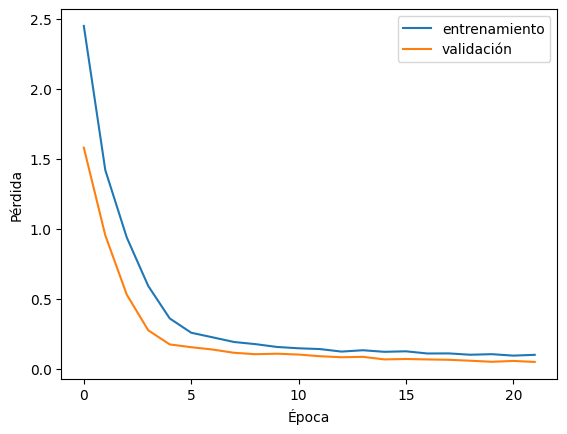

In [11]:
def entrenar_modelo(usar_posicion=True, epocas=22):
    torch.manual_seed(SEMILLA)
    modelo = TraductorTransformer(
        len(vocab_src), len(vocab_tgt), PAD_SRC, PAD_TGT,
        d_modelo=48, cabezas=4, capas=2, d_ff=96,
        dropout=0.1, usar_posicion=usar_posicion,
    ).to(DISPOSITIVO)
    criterio = nn.CrossEntropyLoss(ignore_index=PAD_TGT)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=2e-3)
    historia = {"train": [], "val": []}
    mejor_estado = None
    mejor_val = float("inf")

    for epoca in range(1, epocas + 1):
        perdida_train = ejecutar_epoca(modelo, dl_entrenamiento, criterio, optimizador)
        perdida_val = ejecutar_epoca(modelo, dl_validacion, criterio)
        historia["train"].append(perdida_train)
        historia["val"].append(perdida_val)
        if perdida_val < mejor_val:
            mejor_val = perdida_val
            mejor_estado = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}
        if epoca == 1 or epoca % 5 == 0 or epoca == epocas:
            print(f"época {epoca:02d} | train {perdida_train:.4f} | val {perdida_val:.4f}")

    modelo.load_state_dict(mejor_estado)
    return modelo, historia


modelo, historia = entrenar_modelo(usar_posicion=True)
assert len(historia["train"]) == 22
assert historia["train"][-1] < historia["train"][0]
print("OK - entrenamiento completado")

plt.plot(historia["train"], label="entrenamiento")
plt.plot(historia["val"], label="validación")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.show()

# Ejemplos de funciones utilizadas en este bloque:
# nn.CrossEntropyLoss(...), torch.optim.Adam(...), model.state_dict()
# Tensor.detach().cpu().clone(), plt.plot(...)

## Bloque 5 - Traducir palabra por palabra (10 puntos)

Empiece el decoder con `<SOS>`. En cada paso agregue la palabra con mayor logit y deténgase al producir
`<EOS>` o alcanzar el largo máximo.

In [12]:
@torch.no_grad()
def traducir(modelo, frase_secreta, max_largo=16):
    modelo.eval()

    ids_src = vocab_src.codificar(frase_secreta)
    src = torch.tensor([ids_src], dtype=torch.long, device=DISPOSITIVO)

    sos = vocab_tgt.token_a_id["<SOS>"]
    eos = vocab_tgt.token_a_id["<EOS>"]
    generados = [sos]

    for _ in range(max_largo):
        tgt_entrada = torch.tensor([generados], dtype=torch.long, device=DISPOSITIVO)
        logits = modelo(src, tgt_entrada)
        siguiente = logits[0, -1].argmax().item()
        generados.append(siguiente)
        if siguiente == eos:
            break

    return vocab_tgt.decodificar(generados)


In [13]:
def evaluar_traducciones(modelo, pares, limite=None):
    seleccion = pares if limite is None else pares[:limite]
    tokens_correctos = 0
    tokens_totales = 0
    frases_exactas = 0
    for fila in seleccion:
        pred = traducir(modelo, fila["idioma_secreto"])
        real = fila["espanol"]
        frases_exactas += int(pred == real)
        pred_tokens, real_tokens = pred.split(), real.split()
        largo = max(len(pred_tokens), len(real_tokens))
        tokens_correctos += sum(
            i < len(pred_tokens) and i < len(real_tokens) and pred_tokens[i] == real_tokens[i]
            for i in range(largo)
        )
        tokens_totales += largo
    return {
        "exactitud_tokens": tokens_correctos / tokens_totales,
        "frases_exactas": frases_exactas / len(seleccion),
    }


metricas = evaluar_traducciones(modelo, pares_validacion)
print(metricas)
for fila in pares_validacion[:5]:
    print("secreto :", fila["idioma_secreto"])
    print("esperado:", fila["espanol"])
    print("modelo  :", traducir(modelo, fila["idioma_secreto"]), "\n")

assert 0.0 <= metricas["exactitud_tokens"] <= 1.0
assert metricas["exactitud_tokens"] >= 0.70, "El traductor todavía necesita entrenamiento o correcciones."
print("OK - traductor funcional")

# Ejemplos de funciones utilizadas en este bloque:
# traducir(...), str.split(), max(...), sum(...)

{'exactitud_tokens': 0.9478487614080835, 'frases_exactas': 0.8333333333333334}
secreto : roze fino toda nole boki
esperado: la maestra lleva el perro
modelo  : la maestra lleva el perro 

secreto : roze nali toda fepa moki boki boze
esperado: la médica no lleva el niño feliz
modelo  : la médica no lleva el niño feliz 

secreto : toda moki toda fepa nole dado boze
esperado: el niño no encuentra el perro feliz
modelo  : el perro no encuentra el niño feliz 

secreto : roze mese roze delo nali dado boze
esperado: la gata no encuentra la médica verde
modelo  : la gata no encuentra la médica verde 

secreto : roze nali roze sapa fino boki boze
esperado: la médica no lleva la maestra joven
modelo  : la maestra no lleva la médica joven 

OK - traductor funcional


## Bloque 6 - Reto de investigación aplicado (5 puntos)

Entrene una segunda configuración con `usar_posicion=False`. Registre la pérdida de validación, la
exactitud por token y el porcentaje de frases exactas de ambos modelos. Escriba un párrafo que compare
el resultado con la predicción presentada en la respuesta 3 del Bloque 0.

La comparación debe usar los mismos datos, semilla, arquitectura y cantidad de épocas. No se califica
que la diferencia tenga una dirección específica; se califica que la comparación sea justa y que la
conclusión coincida con la evidencia.

In [14]:
modelo_sin_posicion, historia_sin_posicion = entrenar_modelo(usar_posicion=False)
metricas_sin_posicion = evaluar_traducciones(modelo_sin_posicion, pares_validacion)

resultados = {
    "con_posicion": {
        "mejor_perdida_validacion": min(historia["val"]),
        **metricas,
    },
    "sin_posicion": {
        "mejor_perdida_validacion": min(historia_sin_posicion["val"]),
        **metricas_sin_posicion,
    },
}
print(resultados)

# Ejemplos de funciones utilizadas en este bloque:
# entrenar_modelo(usar_posicion=False), evaluar_traducciones(...), print(...)


época 01 | train 2.4449 | val 1.5841


época 05 | train 0.3450 | val 0.1754


época 10 | train 0.1641 | val 0.1145


época 15 | train 0.1387 | val 0.1113


época 20 | train 0.1254 | val 0.1116


época 22 | train 0.1183 | val 0.1109


{'con_posicion': {'mejor_perdida_validacion': 0.04731343002420805, 'exactitud_tokens': 0.9478487614080835, 'frases_exactas': 0.8333333333333334}, 'sin_posicion': {'mejor_perdida_validacion': 0.10594955208504482, 'exactitud_tokens': 0.7262059973924381, 'frases_exactas': 0.44583333333333336}}


### Comparación y conclusión

| Configuración | Mejor pérdida de validación | Exactitud por token | Frases exactas |
|---|---:|---:|---:|
| Con posición | 0.0473 | 94.78% | 83.33% |
| Sin posición | 0.1059 | 72.62% | 44.58% |

Ambos modelos usan los mismos datos, semilla 42, arquitectura, optimizador y 22 épocas; también conservan el mismo dropout sobre los embeddings. Se evalúa el estado con menor pérdida de validación de cada entrenamiento, por lo que la tabla reporta esa pérdida y las métricas del estado recuperado. El modelo con posición superó al modelo sin posición en exactitud por token, con una diferencia de 22.16 puntos porcentuales. Este resultado coincide con la predicción de la respuesta 3: disponer del orden ayuda a distinguir los papeles de las palabras y reorganizarlas. El modelo sin posición todavía puede aprovechar el vocabulario y los patrones repetitivos del conjunto.

Como limitaciones, solo se utilizó una semilla y un conjunto artificial de frases cortas. Además, la validación se usa tanto para elegir el mejor estado como para reportar métricas, de modo que no sustituye una prueba independiente. Las frases oficiales del concurso permitirían evaluar ejemplos nuevos. No se puede generalizar el tamaño de la diferencia a otros idiomas o secuencias más largas.


## Bloque 7 - Entrega y concurso (5 puntos)

Pegue las frases secretas proporcionadas por el profesor en la lista siguiente. Ejecute la celda para
producir las traducciones que se usarán en la prueba oculta y en el concurso.

In [15]:
frases_del_reto = [
    # "pegue aquí la primera frase secreta",
    # "pegue aquí la segunda frase secreta",
    # "pegue aquí la tercera frase secreta",
]

traducciones_del_reto = [traducir(modelo, frase) for frase in frases_del_reto]
for frase, traduccion in zip(frases_del_reto, traducciones_del_reto):
    print(frase, "->", traduccion)

# Ejemplos de funciones utilizadas en este bloque:
# traducir(...), zip(...), print(...)

### Registro de contribuciones

| Integrante | Investigación y aportes concretos |
|---|---|
| Wilson Calderón | Implementación y verificación de carga de datos, padding, máscaras, Transformer, entrenamiento y evaluación. |
| Nina Nájera | Investigación sobre atención, encoder/decoder y codificación posicional; comparación experimental. |
| Pablo Cabrera | Revisión de la decodificación autoregresiva, análisis de errores y revisión cruzada del experimento posicional. |